# makemore Part 3 — Activations, Gradients, BatchNorm

**Video:** https://www.youtube.com/watch?v=P6sfmUTpUmc  
**Reference notebook:** `../nn-zero-to-hero/lectures/makemore/makemore_part3_bn.ipynb`  
**Paper:** [Batch Normalization (Ioffe & Szegedy 2015)](https://arxiv.org/abs/1502.03167)

## What this notebook builds

Same architecture as Part 2 (Bengio MLP), but with three critical training-stability fixes:

1. **Fix the "hockey stick" starting loss.** Random init makes the model confidently wrong (initial loss ~27, way above the uniform baseline of `log(27) ≈ 3.30`). We initialize output weights near zero so all logits start near uniform. Initial loss drops to ~3.3.

2. **Fix tanh saturation.** With standard `torch.randn` init, hidden pre-activations get so large that `tanh` produces mostly ±1. That kills gradients (`1 - tanh²(x) ≈ 0` at the extremes) — dead neurons. Fix: scale hidden-layer weights by `sqrt(5/3) / sqrt(fan_in)` — Kaiming/He init tuned for tanh.

3. **BatchNorm** — normalize each feature across the batch to zero mean, unit variance, then apply learnable scale/shift. Makes training work even with bad initialization, and unlocks deeper networks.

The video also introduces **diagnostic tooling**: histograms of activations and gradients per layer, which are the standard debugging tools for training instability in real ML work.

## New concepts vs Part 2

- The hockey-stick starting-loss problem + output-layer init fix
- Tanh saturation + Kaiming/He init for tanh
- Activation distribution plots (per-layer histograms)
- Gradient distribution plots (per-layer histograms)
- BatchNorm: mechanics, training vs eval mode, running statistics
- PyTorchification: refactoring to `torch.nn.Linear`, `torch.nn.BatchNorm1d`, `torch.nn.Tanh` module-style code
- Layer normalization (LayerNorm) — the transformer-era replacement for BatchNorm

## Rules (same as Weeks 1-3)

1. **TYPE. Do not paste.**
2. **Pause and predict** before running any new operation.
3. **Break things on purpose** — remove one of the fixes and see how training degrades.
4. **Log what surprised you** in the session log below.

**Every time you open this notebook:** `Kernel → Restart Kernel and Run All Cells`.

## Section 1 — Recap Part 2 setup

Same dataset (`names.txt`), same `stoi`/`itos`, same 80/10/10 split, same `build_dataset` function. This section is fast — just re-establishing the environment.

In [1]:
# Load names, build stoi/itos, split 80/10/10 with block_size=3
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

names = open('names.txt').read().splitlines()
chars = ['.'] + sorted(set(''.join(names)))
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}
vocab_size = len(chars)
block_size = 3

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

random.seed(42); random.shuffle(names)
n1 = int(0.8 * len(names)); n2 = int(0.9 * len(names))
Xtr,  Ytr  = build_dataset(names[:n1])
Xdev, Ydev = build_dataset(names[n1:n2])
Xte,  Yte  = build_dataset(names[n2:])
print(Xtr.shape, Xdev.shape, Xte.shape)

torch.Size([182625, 3]) torch.Size([22655, 3]) torch.Size([22866, 3])


## Section 2 — The "hockey stick" starting loss

**The problem.** With standard `torch.randn` init, the initial cross-entropy loss on this MLP is ~27 — massively higher than the uniform baseline of `log(27) ≈ 3.30`. That means the model at init is *worse than random* — it's *confidently wrong*.

**Why it matters.** The training loss curve has a huge hockey-stick shape at the start: several thousand iterations spent just undoing the bad init. That's compute you could spend on actual learning. It also makes learning-rate tuning harder because you're partly fitting to "escape the bad init" and partly fitting to "learn the data."

**The fix.** Initialize `W2` (the output layer weights) and `b2` (output biases) near zero. Then `logits = h @ W2 + b2` starts near zero for all classes → softmax is uniform → initial loss = `log(27) ≈ 3.30`. No hockey stick.

**Predict:** initial loss before the fix, after the fix?

In [2]:
# Baseline init from Part 2 — measure the hockey-stick loss
g = torch.Generator().manual_seed(2147483647)
n_embd = 10
n_hidden = 200
C  = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters: p.requires_grad = True

emb = C[Xtr]
h = torch.tanh(emb.view(-1, n_embd * block_size) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
print(f"BEFORE fix: initial loss = {loss.item():.4f}  (baseline log(27) = {torch.log(torch.tensor(27.0)).item():.4f})")

BEFORE fix: initial loss = 26.0047  (baseline log(27) = 3.2958)


In [3]:
# Fix by initializing W2 and b2 near zero
g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01   # scale down
b2 = torch.randn(vocab_size, generator=g) * 0                  # zero out
parameters = [C, W1, b1, W2, b2]
for p in parameters: p.requires_grad = True

emb = C[Xtr]
h = torch.tanh(emb.view(-1, n_embd * block_size) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
print(f"AFTER  fix: initial loss = {loss.item():.4f}  (near log(27))")

AFTER  fix: initial loss = 3.3079  (near log(27))


## Section 3 — Tanh saturation

**The problem.** With standard init, pre-activations at the hidden layer are drawn from a distribution with std ≈ `sqrt(fan_in)` — for `fan_in = 30` (block_size=3, n_embd=10), that's std ≈ 5.5. Feeding std-5.5 numbers through `tanh(x)` produces mostly ±1. Look at a histogram of `h` and you see two spikes at ±1 with almost nothing in between.

**Why it matters.** Tanh's derivative is `1 - tanh²(x)`. When `tanh(x) ≈ ±1`, the derivative is ≈ 0 — gradients through those neurons are dead. If a neuron is stuck at ±1 for ALL training examples, its weights never update — it's a permanently dead neuron.

**Diagnostic:** a histogram of `h` values, and a "black-and-white image" showing which (neuron, example) pairs are saturated (|h| > 0.99). If entire rows or columns are all-saturated, you have dead neurons or dead examples.

**Predict:** what fraction of `h` values will be > 0.99 in absolute value with the default init?

fraction saturated: 62.44%


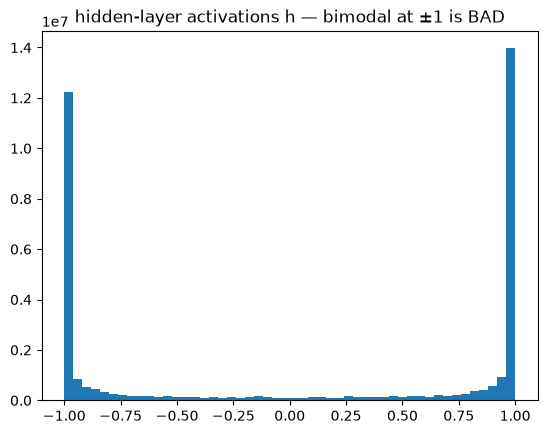

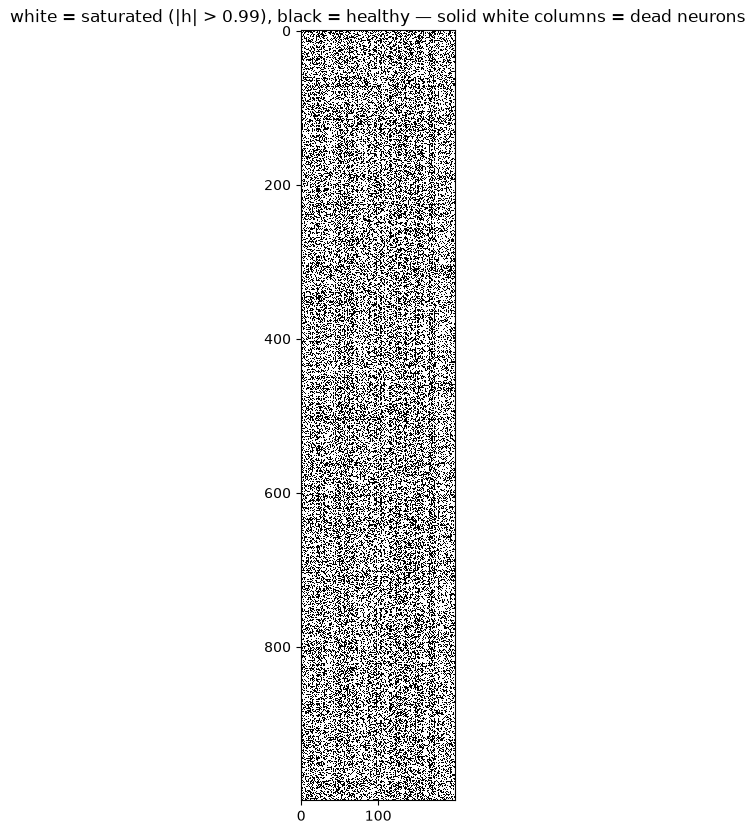

In [4]:
# Plot histogram of h and boolean map of saturation
plt.hist(h.view(-1).tolist(), 50)
plt.title('hidden-layer activations h — bimodal at ±1 is BAD');

saturated = (h.abs() > 0.99).float()
print(f"fraction saturated: {saturated.mean().item():.2%}")
plt.figure(figsize=(20, 10))
plt.imshow(saturated[:1000], cmap='gray', interpolation='nearest')
plt.title('white = saturated (|h| > 0.99), black = healthy — solid white columns = dead neurons');

## Section 4 — Kaiming (He) initialization

**The principled fix.** Kaiming He derived (2015) the correct scaling for weights that preserves activation variance across layers. For a linear layer with `fan_in` inputs feeding into a `gain`-sensitive nonlinearity:

```
W ~ N(0, gain / sqrt(fan_in))
```

**`gain` values (from PyTorch docs):**
- Linear / identity: `1.0`
- Tanh: `5/3` ≈ `1.667`
- ReLU: `sqrt(2)` ≈ `1.414`
- Leaky ReLU: `sqrt(2 / (1 + slope²))`

**Why this specific formula:** to keep `Var(out) = Var(in)` across a layer. Each output element is a sum of `fan_in` products, and the variance of that sum scales linearly with `fan_in`. Dividing by `sqrt(fan_in)` cancels it. The `gain` corrects for the specific nonlinearity's effect on variance.

**Predict:** after fixing W1 with Kaiming init, what's the fraction of saturated `h` values?

h mean: 0.041, std: 0.749
fraction saturated: 9.97%


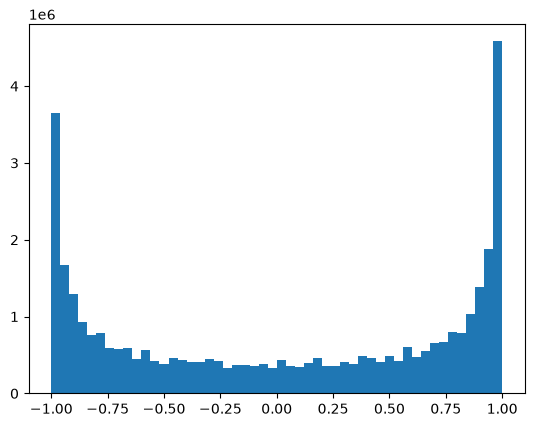

In [5]:
# Use Kaiming init for W1 (tanh nonlinearity → gain=5/3)
g = torch.Generator().manual_seed(2147483647)
n_input = n_embd * block_size
C  = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_input, n_hidden), generator=g) * (5/3) / (n_input ** 0.5)   # Kaiming for tanh
b1 = torch.randn(n_hidden, generator=g) * 0.01                                    # small bias
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0
parameters = [C, W1, b1, W2, b2]
for p in parameters: p.requires_grad = True

emb = C[Xtr]
h = torch.tanh(emb.view(-1, n_input) @ W1 + b1)
print(f"h mean: {h.mean().item():.3f}, std: {h.std().item():.3f}")
print(f"fraction saturated: {(h.abs() > 0.99).float().mean().item():.2%}")
plt.hist(h.view(-1).tolist(), 50);


## Section 5 — BatchNorm

**The idea.** For each hidden dimension, normalize the pre-activation across the batch: subtract the batch mean, divide by the batch std. Then apply a learnable per-dimension scale (`bngain`) and shift (`bnbias`) so the network can undo the normalization if it wants.

```python
# During training:
hpreact = flat @ W1 + b1                            # pre-activation, shape (batch, n_hidden)
bnmean = hpreact.mean(0, keepdim=True)              # (1, n_hidden) — mean per feature across batch
bnstd  = hpreact.std(0, keepdim=True)               # (1, n_hidden)
hpreact_normed = (hpreact - bnmean) / bnstd         # zero mean, unit variance per feature
hpreact_final = bngain * hpreact_normed + bnbias    # learnable rescale + shift
h = torch.tanh(hpreact_final)
```

**Why it works.** BatchNorm forces each layer's activations to have controlled statistics *regardless* of what the incoming weights are. This makes training robust to initialization — you can be lazy about weight init and still train.

**Two subtleties:**
1. **Training vs eval.** At inference time, you don't have a batch — so BN uses `running_mean` and `running_std` accumulated during training (via exponential moving average). Model must know which mode it's in.
2. **Batch coupling.** BN links different training examples together — one example's normalization depends on the others in the batch. This is often useful (acts as regularization) but breaks in some contexts (variable-length sequences, tiny batch sizes).

In [6]:
# Rebuild the model with BatchNorm inserted after W1 @ input, before tanh
g = torch.Generator().manual_seed(2147483647)
n_input = n_embd * block_size
C  = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_input, n_hidden), generator=g) * (5/3) / (n_input ** 0.5)
# b1 no longer needed — BN's bnbias replaces it
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running  = torch.ones((1, n_hidden))
parameters = [C, W1, W2, b2, bngain, bnbias]
for p in parameters: p.requires_grad = True

# Forward with BN (training mode)
emb = C[Xtr]
hpreact = emb.view(-1, n_input) @ W1     # no b1 — BN adds bias via bnbias
bnmean_i = hpreact.mean(0, keepdim=True)
bnstd_i  = hpreact.std(0, keepdim=True)
hpreact = bngain * (hpreact - bnmean_i) / bnstd_i + bnbias
with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmean_i
    bnstd_running  = 0.999 * bnstd_running  + 0.001 * bnstd_i
h = torch.tanh(hpreact)
print(f"h mean: {h.mean().item():.3f}, std: {h.std().item():.3f}")
print(f"fraction saturated: {(h.abs() > 0.99).float().mean().item():.2%}")

h mean: -0.001, std: 0.629
fraction saturated: 0.83%


## Section 6 — Full training with all three fixes

Now put it all together: hockey-stick fix + Kaiming init + BatchNorm. Train for ~30k iterations at lr=0.1, decaying to 0.01. Expected dev loss: ~2.10-2.15, meaningfully better than Part 2's ~2.20.

**Predict:** compared to Part 2's dev 2.20, how much will the BN version improve?

In [7]:
# Training loop with mini-batch SGD + BN update
for i in range(30000):
    # mini-batch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    # forward
    emb = C[Xtr[ix]]
    hpreact = emb.view(-1, n_input) @ W1
    bnmean_i = hpreact.mean(0, keepdim=True)
    bnstd_i  = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmean_i) / bnstd_i + bnbias
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmean_i
        bnstd_running  = 0.999 * bnstd_running  + 0.001 * bnstd_i
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    # backward
    for p in parameters: p.grad = None
    loss.backward()
    # update
    lr = 0.1 if i < 20000 else 0.01
    for p in parameters: p.data += -lr * p.grad
    if i % 5000 == 0:
        print(f"{i:5d}  loss = {loss.item():.4f}")

# Evaluate on train + dev using RUNNING stats (not batch stats!)
@torch.no_grad()
def eval_loss(X, Y):
    emb = C[X]
    hpreact = emb.view(-1, n_input) @ W1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias   # RUNNING stats
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    return F.cross_entropy(logits, Y).item()
print(f"train: {eval_loss(Xtr,  Ytr ):.4f}")
print(f"dev:   {eval_loss(Xdev, Ydev):.4f}")

    0  loss = 3.2752


 5000  loss = 2.3540


10000  loss = 2.5603


15000  loss = 2.2893


20000  loss = 1.9828


25000  loss = 2.3821


train: 2.1482
dev:   2.1648


## Section 7 — PyTorchify + Diagnostic Tooling

To use Karpathy's diagnostic plots, we first need the model in `torch.nn`-style module form — because the diagnostics iterate over `layers` and inspect each layer's `.out` attribute. So the pytorchification happens **here** (not in a separate later section), then a training loop with per-layer instrumentation, then four diagnostic plots.

**A design note on this section's network.** The layer stack below uses `Linear → BatchNorm1d → Tanh` blocks and applies the hockey-stick fix as `layers[-1].gamma *= 0.1` (scaling the final BatchNorm's γ instead of the output weight). Because BatchNorm normalizes activations to unit variance regardless of weight scale, we also DON'T need Kaiming's `/sqrt(fan_in)` scaling — the `Linear` class here uses plain `torch.randn` without division. That's the ultimate lesson of this video: **BN makes weight init much less sensitive.** Kaiming becomes a "nice-to-have" instead of a "must-have."

### The four diagnostic plots

**The unifying principle:** healthy = all layers/parameters look identical. Overlap = statistical consistency across depth. Divergence = something is wrong.

**1. Activation distributions per layer** — histogram of `tanh` output values.
- ✅ Healthy: all layers overlap, roughly uniform density across [-1, +1].
- ❌ Unhealthy: bimodal spikes at ±1 (saturation) or thin spike at 0 (collapse).

**2. Layer-output gradient distributions** — histogram of `layer.out.grad` = ∂L/∂h (the gradient of loss w.r.t. the tanh output, BEFORE tanh's derivative gets applied).
- ✅ Healthy: all layers overlap, forming a single bell curve.
- ❌ Unhealthy: distributions shifted narrower for early layers (vanishing) or wider (exploding).

**3. Weight gradient distributions** — histogram of `p.grad` for each 2D weight tensor, with a `grad:data ratio` print (`p.grad.std() / p.data.std()`) that gives the **relative** scale of gradients.
- ✅ Healthy: all weight-grad histograms overlap; grad:data ratio in a similar order of magnitude across layers.
- ❌ Unhealthy: one layer's ratio is much larger than the others (that layer will move disproportionately fast).

**4. Update-to-data ratio over training time** — for each 2D parameter, plot `log10(lr × p.grad.std() / p.data.std())` at every training step. The black `-3` reference line marks the sweet spot: an update of ~0.1% of the weight's magnitude per step.
- ✅ Healthy: all curves hover near -3 throughout training.
- ❌ Too high (curves way above -3): `lr` is too large; weights change too much per step.
- ❌ Too low (curves way below -3): `lr` is too small or gradients are dying; parameters aren't learning.

These four plots together are the standard debugging toolkit for training instability in real ML work. If a network won't train, this is where you look first.

In [8]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) #/ fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True, unbiased=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

n_embd = 10
n_hidden = 100
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator = g)
layers = [
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size), BatchNorm1d(vocab_size)
]

with torch.no_grad():
    # layers[-1].weight *= 0.1
    layers[-1].gamma *= 0.1
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 1 #5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

47551


In [9]:
# Training loop with per-layer activation retention (for the diagnostic plots)
max_steps = 20000
batch_size = 32
lossi = []
ud = []   # update-to-data ratio history (log10), one row per step

for i in range(max_steps):

    # mini-batch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    # backward — retain_grad() so we can inspect each layer's .out.grad for plot #2
    # (normally intermediate .grad is freed to save memory; retain_grad tells autograd to keep it)
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 15000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track update-to-data ratio (for plot #4) — log10 of |update|/|weight|
    with torch.no_grad():
        ud.append([((lr * p.grad).std() / p.data.std()).log10().item() for p in parameters])

    if i % 2000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

print(f"\nfinal loss: {loss.item():.4f}")

      0/  20000: 3.2870


   2000/  20000: 2.9143


   4000/  20000: 2.1498


   6000/  20000: 2.2694


   8000/  20000: 2.3579


...

  12000/  20000: 2.6165


  14000/  20000: 2.6955


  16000/  20000: 2.0281


  18000/  20000: 2.3476



final loss: 2.2129


layer 2 (      Tanh): mean +0.02, std 0.61, saturated: 2.59%
layer 5 (      Tanh): mean -0.01, std 0.62, saturated: 3.16%
layer 8 (      Tanh): mean -0.03, std 0.63, saturated: 2.91%
layer 11 (      Tanh): mean -0.01, std 0.63, saturated: 2.94%
layer 14 (      Tanh): mean -0.00, std 0.62, saturated: 2.59%


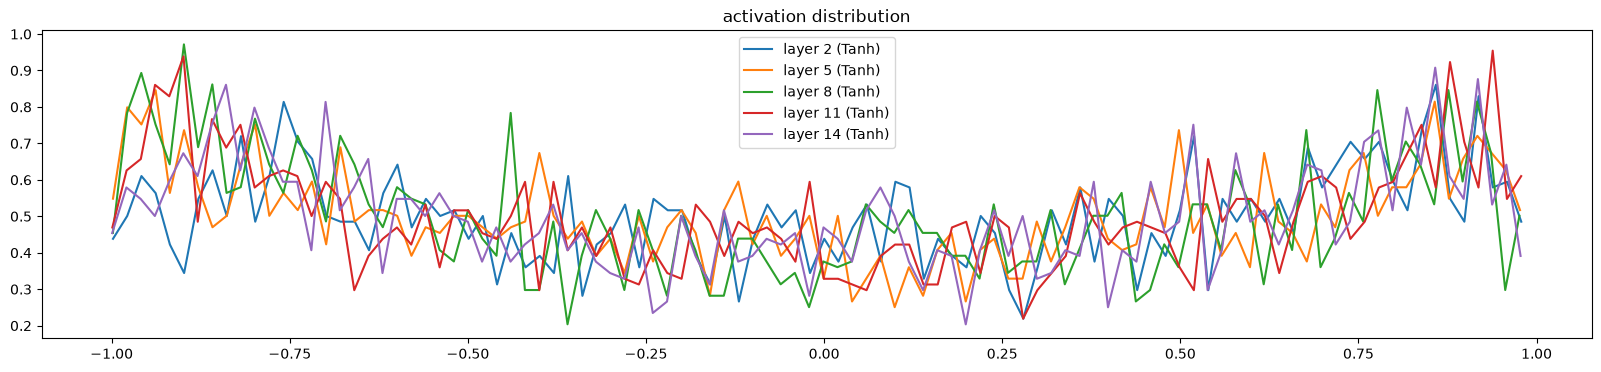

In [10]:
# Activation distribution plot (per layer)
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean().item(), t.std().item(), (t.abs() > 0.97).float().mean().item()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('activation distribution');

layer 2 (      Tanh): mean -0.000000, std 5.621013e-03
layer 5 (      Tanh): mean +0.000000, std 4.740150e-03
layer 8 (      Tanh): mean -0.000000, std 4.651334e-03
layer 11 (      Tanh): mean -0.000000, std 4.458541e-03
layer 14 (      Tanh): mean -0.000000, std 4.258664e-03


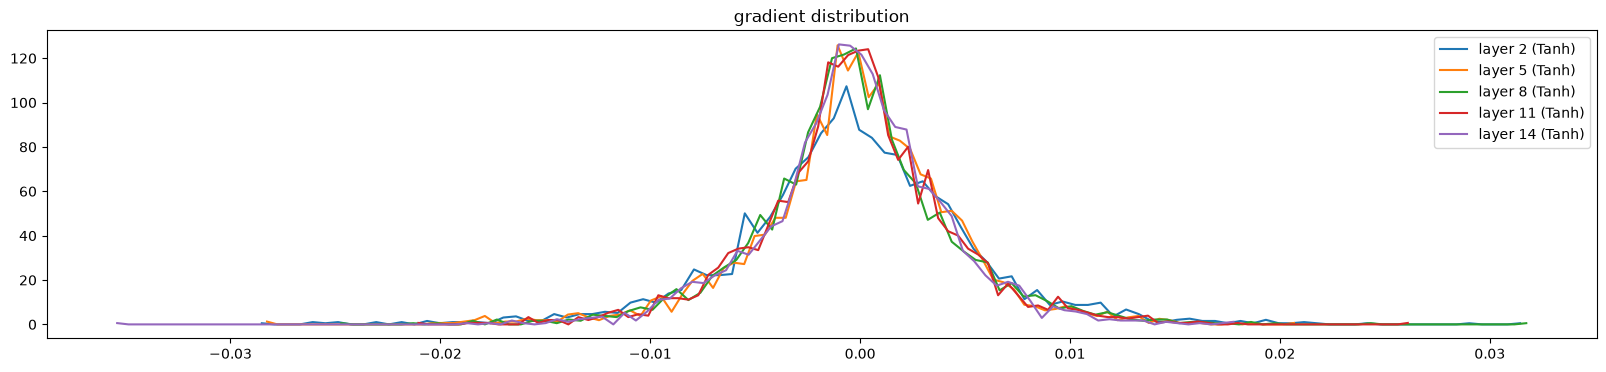

In [11]:
# Gradient distribution plot (per layer)
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('gradient distribution');

weight   (27, 10) | mean -0.000000 | std 1.043681e-02 | grad:data ratio 1.034346e-02


weight  (30, 100) | mean -0.000006 | std 3.354005e-03 | grad:data ratio 3.270207e-03
weight (100, 100) | mean -0.000008 | std 1.740321e-03 | grad:data ratio 1.745659e-03
weight (100, 100) | mean +0.000011 | std 1.620252e-03 | grad:data ratio 1.608235e-03
weight (100, 100) | mean -0.000002 | std 1.574914e-03 | grad:data ratio 1.569816e-03
weight (100, 100) | mean +0.000028 | std 1.484381e-03 | grad:data ratio 1.478174e-03
weight  (100, 27) | mean +0.000020 | std 2.849538e-03 | grad:data ratio 2.880777e-03


/var/folders/d5/y4rzkr7x2cg2vk8q7hp41c480000gn/T/ipykernel_10934/2025602850.py:10: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:823.)
  print('weight %10s | mean %+f | std %e | grad:data ratio %e' %


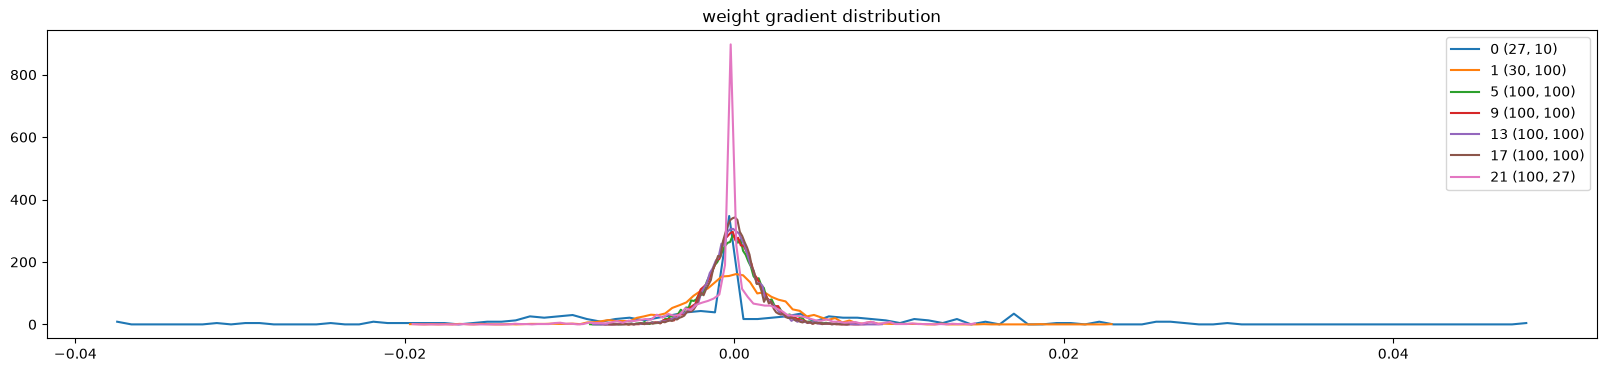

In [12]:
# Diagnostic plot #3 — Weight gradient distributions per 2D parameter.
# The `grad:data ratio` print is the relative scale — small ratio means the weight is barely moving,
# large ratio means the weight is changing a lot per gradient. Look for ratios in a similar order
# of magnitude across parameters; a single layer with a much larger ratio moves disproportionately fast.
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' %
              (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weight gradient distribution');

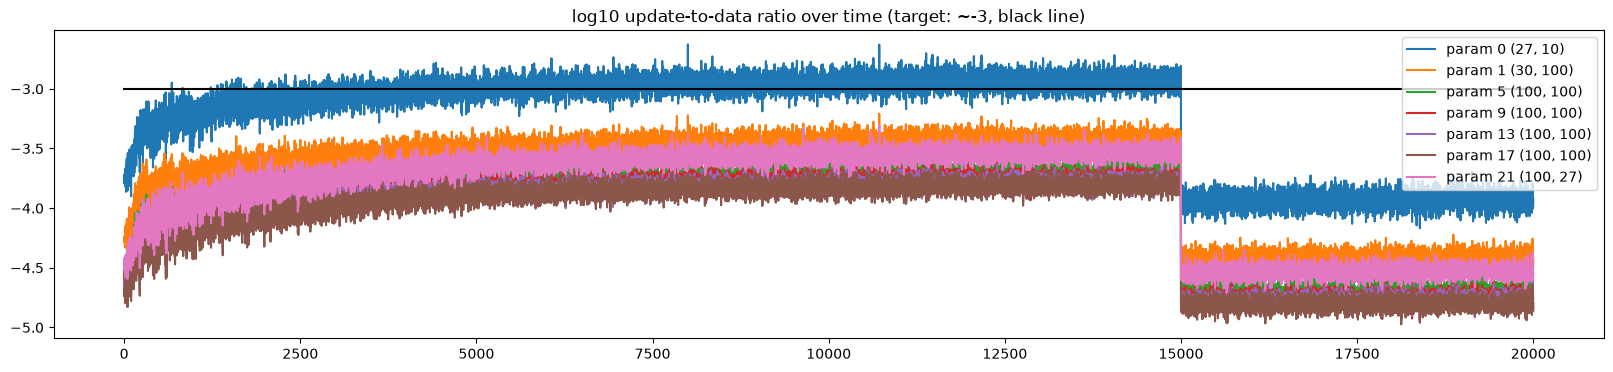

In [13]:
# Diagnostic plot #4 — Update-to-data ratio over training time (log10 scale).
# Each curve is one 2D parameter. Black horizontal line at -3 marks the healthy zone:
# an update of ~0.1% of the weight's magnitude per step. Above -3 = lr too high; below -3 = lr too low.
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append(f'param {i} {tuple(p.shape)}')
plt.plot([0, len(ud)], [-3, -3], 'k')   # target: ~10^-3 relative update per step
plt.legend(legends)
plt.title('log10 update-to-data ratio over time (target: ~-3, black line)');

## Section 8 — Sample from the trained model

Sampling with BatchNorm is subtle: you MUST use `running_mean` / `running_var`, not batch stats (a batch of 1 has trivial stats). The loop below iterates all layers and switches each `BatchNorm1d` to `eval` mode before sampling, so the BN blocks use their exponential-moving-average running statistics instead.

*Not shown in Karpathy's Part 3 video — added here for a complete end-to-end pipeline.*

In [14]:
# Sample 20 names from the trained model — BN switched to eval mode uses running stats
for layer in layers:
    if isinstance(layer, BatchNorm1d):
        layer.training = False

g = torch.Generator().manual_seed(2147483647 + 10)
for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        x = emb.view(1, -1)
        for layer in layers: x = layer(x)
        probs = F.softmax(x, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        if ix == 0: break
        out.append(itos[ix])
    print(''.join(out))

carelixatleil
khi
mri
reetl
salaysa
jazonen
dellynn
kaqhi
neroniah
maiiv
kalein
dham
join
quinn
shorlea
jadbi
wazelo
dearixi
jameeniluan
ed


## Session log

### What clicked

- **The hockey stick was a result of extreme random init.** Setting output weights near zero pre-optimizes the training pipeline — the model starts at the uniform-guess baseline instead of "confidently wrong." Same trick works via the final BatchNorm's γ (multiplying it by 0.1 instead of the weight matrix).
- **Now I see why transformer attention divides by √d_k.** If activations at the input to `tanh` (or `sigmoid`) are too big, they fall in the flat/saturated regions → no gradient → no learning. The `/√d_k` in attention keeps the pre-softmax scores at std ~1 for the same reason: keep the softmax out of its flat regions where gradients die. Different function, same principle.
- **The "squashing" cascade.** If the initial gain isn't set high enough, each `tanh` layer shrinks its output slightly, and the next `tanh` shrinks it further. After a few layers, outputs cluster near zero and the tanhs become effectively linear — losing the nonlinearity that makes depth valuable.
- **Random weights can be worse than zero weights.** Not because random is bad in principle, but because "large random" pushes activations into tanh's saturated flats. Small random (or scaled Kaiming random) is the sweet spot. Zero exactly would break symmetry (see Q&A below).
- **Massive tanh saturation with default init.** With standard `torch.randn` and no scaling, a huge fraction of activations end up in |h| > 0.99 — a huge chunk of the network is effectively dead. Kaiming init dramatically reduces this.
- **ReLU has its own dead-neuron problem.** ReLU outputs zero for all negative inputs. If a neuron's weights push it always-negative, it never fires, and its weights never update (dead ReLU). Leaky ReLU (or GELU, SiLU) has non-zero slope everywhere → no truly flat zones → can't get permanently dead.
- **"Healthy" = all layers look identical.** The specific shape of the activation or gradient distribution doesn't matter as much as the fact that every layer's distribution *overlaps* with every other layer's. That's what Kaiming init and BatchNorm both aim for: statistical consistency across depth.
- **BatchNorm makes weight init much less critical.** The final network in Section 7 uses `torch.randn` weights with NO Kaiming scaling — BN normalizes activations to unit variance regardless of what the weights are. Kaiming becomes a nice-to-have; BN is the actual heavy lifter. The tradeoff: BN adds a whole new set of problems (see the BN Q&A below).
- **Four diagnostic plots, not two.** Karpathy uses (1) activation distributions, (2) layer-output gradient distributions, (3) weight-gradient distributions with grad:data ratio, and (4) update-to-data ratio over time with a `-3` reference line. Together these tell you whether your network is well-tuned; if not, they tell you which layer is broken.
- **The `-3` target for update:data ratio.** An update of ~10⁻³ of the weight's magnitude per step is the healthy zone. Way above = lr too high (weights change too much per step); way below = lr too low or gradients dying. Watch these curves during training as a real-time lr sanity check.
- **Karpathy's video scaffolding split "diagnostics" (Section 7) from "torchify" (Section 8), but the diagnostics iterate over `layers` and inspect `layer.out` — which requires the module refactor first.** Restructured the notebook to combine them into one Section 7 that reflects what actually happens.

### Questions I had (and the answers I found)

**Q: Why is a gain of `5/3` specifically necessary for `tanh`?**

*A: **`tanh` compresses variance.** Kaiming's clean derivation assumes an identity nonlinearity (input variance = output variance). But `tanh` squashes its inputs toward ±1, which shrinks the output variance below the input variance. Empirically, feeding Gaussian input with variance 1 through `tanh` produces output with variance ≈ 3/5. To compensate — so the OUTPUT of tanh keeps unit variance across layers — we boost the incoming weights by the reciprocal: `5/3`. Other nonlinearities have their own gains for the same reason: `sqrt(2)` for ReLU (which drops half the mass to zero), `1.0` for identity (no compression).*

**Q: Where does "fan-in" come from?**

*A: **It's the number of inputs "fanning in" to a neuron.** Visualize a single output neuron with wires coming in from many input neurons — those wires "fan in" like a folding fan. For a Linear layer of shape `(fan_in, fan_out)`, each output neuron sums `fan_in` weighted inputs. The Kaiming scaling `1/sqrt(fan_in)` cancels the variance-growth-with-fan_in effect: each of those `fan_in` products contributes variance ~1, they sum, total variance ~fan_in, dividing weights by sqrt(fan_in) shrinks each product's variance to 1/fan_in, sum stays at 1. `fan_out` is the corresponding count for the reverse direction; some initialization schemes average fan_in and fan_out.*

**Q: If pre-activations are small, they're in tanh's steep max-gradient region — why isn't that ideal for learning?**

*A: **Two separate effects — I was right about ONE of them, missing another.** Yes, small inputs are in tanh's steep region where local gradient is ~1 (great local signal). BUT: for small `x`, `tanh(x) ≈ x` — tanh is nearly linear. A stack of near-linear layers collapses to a single linear function (matrix multiplications compose), and you lose the entire point of depth. Multiple layers with tiny pre-activations give you no more representational power than a single linear layer. The sweet spot: pre-activations big enough to actually USE the nonlinearity, but not so big that they saturate. Kaiming's `5/3 / sqrt(fan_in)` targets exactly this.*

**Q: Why does higher gain (more tanh saturation) produce a WIDER gradient distribution at `layer.out.grad`, not narrower?**

*A: **Because you're plotting the gradient BEFORE tanh's derivative kills it.** This is subtle but important:*
- *`layer.out` is `tanh(pre_activation)`. `layer.out.grad` = dL/dh (the gradient of loss w.r.t. the tanh output).*
- *That gradient equals `dL/dh_next @ W_next.T` — it depends on the NEXT layer's weights, not tanh's derivative.*
- *Higher gain in the next layer = larger `W_next` = larger gradient magnitude arriving at THIS layer's `.out.grad`.*
- *So higher gain widens the gradient distribution at every tanh output, even though many neurons are saturated.*
- ***Where the saturation actually kills things** is when we backprop THROUGH tanh to the pre-activation: the gradient there gets multiplied by `(1 - tanh²(x))`, which is ≈ 0 at saturation. Weights of the previous Linear layer see very small updates for saturated pre-activations.*
- *So "wider gradient at tanh output" and "saturated neurons don't learn" are consistent — different points in the computation graph.*

**Q: Why can't I initialize the weights to exactly zero?**

*A: **Symmetry never breaks.** If every weight in a layer is zero, every neuron computes the same output for the same input. Every neuron receives the same gradient. Every neuron's update is identical. Neurons never differentiate — they all learn the same feature, and the layer effectively acts like ONE neuron. Random init (even small random, like Kaiming) breaks the symmetry so neurons diverge and specialize. There are exceptions (BatchNorm's γ starts at 1, β at 0 — those are learnable per-dimension scalars, not weight matrices; symmetry isn't relevant).*

**Q: Why was Kaiming initialization only applied to some layers, not others?**

*A: **Different layers have different roles.** Look at what got what init in Sections 4-6:*
- *Hidden layer weights (`W1`): Kaiming with tanh gain `5/3` → preserves activation variance forward through the network.*
- *Output layer weights (`W2`): scaled by 0.01 → intentionally SMALL so all logits start near zero → uniform softmax → initial loss = log(vocab_size). This is the hockey-stick fix.*
- *Output layer bias (`b2`): scaled by zero → same reason as above.*
- *Hidden layer bias (`b1`): scaled by 0.01 → small nonzero bias, doesn't need to be big.*

*So Kaiming isn't "only applied to first weights" — it's applied to every layer whose job is variance preservation. The output layer has a different job (start uniform), so it gets a different init. In the final Section-7 network with BN everywhere, we skip Kaiming entirely — BN handles the variance normalization, and the hockey-stick fix moves from `W2 *= 0.01` to `layers[-1].gamma *= 0.1`.*

**Q: Does `@` do matrix multiplication and `*` do element-wise?**

*A: **Yes — exactly right.***
- *`A @ B` is matrix multiplication (dot product convention): `A.shape[-1]` must equal `B.shape[-2]`; the result's shape is `A.shape[:-1] + B.shape[-1:]`.*
- *`A * B` is element-wise (Hadamard): both tensors must have compatible shapes for broadcasting; result shape follows broadcasting rules.*
- *`A.matmul(B)` is a synonym for `@`. `torch.mul(A, B)` is a synonym for `*`.*
- *`A.dot(B)` is 1D-vector dot product only (returns a scalar); for 2D+, use `@`.*

**Q: BatchNorm is famously problematic in practice — what are the actual drawbacks, and what alternatives replaced it?**

*A: **Three real problems, and the transformer-era alternatives that fix them.***

*The three headaches:*
1. ***Batch-size dependence.** BN's normalization statistics are computed across the batch — with a batch of 4, your "batch mean" is a noisy estimate of 4 numbers, and models trained with small batches perform worse. With a batch of 1 (inference), you can't compute batch stats at all → you MUST fall back on running-mean/running-var, which introduces a train/eval mode split that can silently be wrong.*
2. ***Batch coupling.** BN links every example in the batch together — one example's output depends on the other examples that happened to be alongside it. This breaks certain problems: variable-length sequences (transformers with padding), contrastive learning (where the batch composition is the whole point), and any setup where you want per-example reproducibility.*
3. ***Distributed training weirdness.** When training across GPUs, do you sync BN stats across devices or compute them locally? Both choices have failure modes. Synchronization adds communication overhead; not synchronizing produces inconsistent statistics.*

*The transformer-era alternatives:*
- ***LayerNorm** — normalize across features WITHIN one example instead of across examples in a batch. Removes batch dependence entirely. This is what transformers use.*
- ***RMSNorm** — an even simpler LayerNorm variant (skip the mean-centering, just scale by RMS). Used in Llama, Mistral, most recent LLMs.*
- ***GroupNorm** — a compromise between LayerNorm and BN, used in some computer vision.*

*The unifying theme: they all achieve the same goal (control activation statistics across depth) without BN's batch-dependence problems.*

### Still-open questions

- If the standard deviation of activations coming INTO an activation function is too small (much less than 1), does that also make learning harder — kind of an "underdamped response" to loss minimization? (Partially answered by the small-preact Q above: yes, near-linear behavior collapses the network's effective depth, but the *local* gradient is still healthy. So it's less "no learning" and more "no benefit from depth.")

### What surprised me

- **Random weights can be worse than zero weights for the OUTPUT layer.** Not obvious at first — random should be neutral. But near-zero output init aligns the model with the uniform-baseline prior, which is closer to truth than "confidently wrong random guesses" at init. Rate of accurate generalization during training is faster.
- **The amount of tanh saturation with default init is shocking.** My initial guess: 50% at `|h| > 0.99` before Kaiming, 5% after. Reality was much worse before and better after. Almost the entire network can be effectively dead at init if you don't scale weights properly.
- **ReLU has its own dead-neuron mode.** ReLU's flat region is only on the negative side, but if a neuron gets pushed always-negative early in training, it never fires. Hence Leaky ReLU / GELU / SiLU — activation functions with no truly flat zones.
- **The connection to transformer attention.** Karpathy's `/√fan_in` for keeping tanh in the linear region and the transformer's `/√d_k` in scaled dot-product attention are the SAME principle: keep pre-softmax/pre-tanh inputs at variance ~1 so the nonlinearity operates in its useful regime. Different functions, same math.
- **BatchNorm makes Kaiming init optional.** After adding BN to every layer, I dropped the `/sqrt(fan_in)` scaling on the Linear class and the network still trained fine. BN's per-feature normalization compensates for whatever weight scale you happen to choose. That's a big deal — it's why "just add BatchNorm" was the standard fix for years before LayerNorm took over in transformers.